In [1]:
# Paso 1: importar librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignorar warnings
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [2]:
# Paso 2: cargar el dataset final generado en el notebook 03

def cargar_dataset(ruta):
    """
    Carga el dataset final en formato pickle.

    Parametros
    ----------
    ruta : str
        Ruta donde se encuentra guardado el archivo pickle.

    Devuelve
    --------
    pd.DataFrame
        Dataset final cargado en memoria.
    """

    df = pd.read_pickle(ruta)

    return df


df = cargar_dataset("../data/processed/ecommerce_brazil_final.pkl")

df.shape

(99441, 51)

In [3]:
# Paso 3: seleccionar variables numéricas relevantes para el análisis estadístico

variables_numericas = [
    "order_total_value",
    "order_products_value",
    "order_freight_value",
    "total_items",
    "total_products",
    "total_payment_value",
    "approval_time_hours",
    "carrier_delivery_days",
    "customer_delivery_days",
    "estimated_delivery_days",
    "delay_days",
    "freight_ratio",
    "avg_product_value_per_item",
    "payment_difference"
]

df_numerico = df[variables_numericas]

df_numerico.head()

,order_total_value,order_products_value,order_freight_value,total_items,total_products,total_payment_value,approval_time_hours,carrier_delivery_days,customer_delivery_days,estimated_delivery_days,delay_days,freight_ratio,avg_product_value_per_item,payment_difference
0,38.71,29.99,8.72,1,1,38.71,0.178333,2.366493,8.436574,15.544063,-7.107488,0.225265,29.99,0.000000e+00
1,141.46,118.70,22.76,1,1,141.46,30.713889,0.462882,13.782037,19.137766,-5.355729,0.160894,118.70,0.000000e+00
2,179.12,159.90,19.22,1,1,179.12,0.276111,0.204595,9.394213,26.639711,-17.245498,0.107302,159.90,0.000000e+00
3,72.20,45.00,27.20,1,1,72.20,0.298056,3.745833,13.208750,26.188819,-12.980069,0.376731,45.00,0.000000e+00
4,28.62,19.90,8.72,1,1,28.62,1.030556,0.893113,2.873877,12.112049,-9.238171,0.304682,19.90,3.552714e-15


In [4]:
# Paso 4: revisar valores nulos en las variables numéricas seleccionadas

def revisar_nulos(df):
    """
    Calcula el número y porcentaje de valores nulos por columna.

    Parametros
    ----------
    df : pd.DataFrame
        DataFrame con las variables que se quieren revisar.

    Devuelve
    --------
    pd.DataFrame
        Tabla con columnas, número de nulos y porcentaje de nulos.
    """

    resultado = pd.DataFrame({
        "nulos": df.isna().sum(),
        "porcentaje_nulos": df.isna().mean() * 100
    })

    resultado = (
        resultado
        .sort_values("porcentaje_nulos", ascending=False)
        .round(2)
    )

    return resultado


revisar_nulos(df_numerico)

,nulos,porcentaje_nulos
delay_days,2965,2.98
customer_delivery_days,2965,2.98
carrier_delivery_days,1797,1.81
payment_difference,776,0.78
order_total_value,775,0.78
order_products_value,775,0.78
freight_ratio,775,0.78
total_products,775,0.78
total_items,775,0.78
order_freight_value,775,0.78


In [5]:
# Paso 5: calcular estadísticos descriptivos principales

def resumen_estadistico(df):
    """
    Genera un resumen estadístico de las variables numéricas.

    Incluye conteo, media, desviación estándar, mínimo,
    percentiles principales y máximo.

    Parametros
    ----------
    df : pd.DataFrame
        DataFrame con variables numéricas.

    Devuelve
    --------
    pd.DataFrame
        Resumen estadístico transpuesto.
    """

    resumen = df.describe().T

    return resumen


resumen_estadistico(df_numerico)

,count,mean,std,min,25%,50%,75%,max
order_total_value,98666.0,160.577638,220.466087,9.59,61.98,105.29,176.87,13664.08
order_products_value,98666.0,137.754076,210.645145,0.85,45.9,86.9,149.9,13440.0
order_freight_value,98666.0,22.823562,21.650909,0.0,13.85,17.17,24.04,1794.96
total_items,98666.0,1.141731,0.538452,1.0,1.0,1.0,1.0,21.0
total_products,98666.0,1.038098,0.226456,1.0,1.0,1.0,1.0,8.0
total_payment_value,99440.0,160.990267,221.951257,0.0,62.01,105.29,176.97,13664.08
approval_time_hours,99281.0,10.419094,26.038004,0.0,0.215,0.343333,14.580833,4509.180556
carrier_delivery_days,97644.0,2.805038,3.549427,-171.219005,0.875509,1.818397,3.580469,125.762569
customer_delivery_days,96476.0,12.558702,9.54653,0.533414,6.766403,10.217755,15.720327,209.628611
estimated_delivery_days,99441.0,23.76765,8.832371,1.648993,18.33169,23.24037,28.424861,155.135463


In [6]:
# Paso 6: comparar media y mediana para detectar posibles asimetrías

def comparar_media_mediana(df):
    """
    Compara la media y la mediana de cada variable numérica.

    Esta comparación ayuda a detectar distribuciones asimétricas.
    Cuando la media es muy superior a la mediana, suele indicar
    presencia de valores extremos altos.

    Parametros
    ----------
    df : pd.DataFrame
        DataFrame con variables numéricas.

    Devuelve
    --------
    pd.DataFrame
        Tabla con media, mediana y diferencia entre ambas.
    """

    resultado = pd.DataFrame({
        "media": df.mean(),
        "mediana": df.median()
    })

    resultado["diferencia_media_mediana"] = (
        resultado["media"] - resultado["mediana"]
    )

    return resultado.round(2)


comparar_media_mediana(df_numerico)

,media,mediana,diferencia_media_mediana
order_total_value,160.58,105.29,55.29
order_products_value,137.75,86.9,50.85
order_freight_value,22.82,17.17,5.65
total_items,1.14,1.0,0.14
total_products,1.04,1.0,0.04
total_payment_value,160.99,105.29,55.7
approval_time_hours,10.42,0.34,10.08
carrier_delivery_days,2.81,1.82,0.99
customer_delivery_days,12.56,10.22,2.34
estimated_delivery_days,23.77,23.24,0.53


In [7]:
# Paso 7: analizar asimetría y curtosis de las variables numéricas

def analizar_forma_distribucion(df):
    """
    Calcula asimetría y curtosis de las variables numéricas.

    La asimetría permite identificar si la distribución está sesgada
    hacia valores altos o bajos.

    La curtosis permite evaluar si existen colas pesadas o valores
    extremos más frecuentes de lo esperado.

    Parametros
    ----------
    df : pd.DataFrame
        DataFrame con variables numéricas.

    Devuelve
    --------
    pd.DataFrame
        Tabla con asimetría y curtosis por variable.
    """

    resultado = pd.DataFrame({
        "asimetria": df.skew(),
        "curtosis": df.kurtosis()
    })

    return resultado.round(2)


analizar_forma_distribucion(df_numerico)

,asimetria,curtosis
order_total_value,9.23,239.68
order_products_value,9.73,266.07
order_freight_value,12.05,565.34
total_items,7.53,114.85
total_products,8.11,98.79
total_payment_value,9.15,233.41
approval_time_hours,56.98,9122.95
carrier_delivery_days,3.67,116.46
customer_delivery_days,3.83,39.31
estimated_delivery_days,0.99,5.25


In [8]:
# Paso 8: calcular matriz de correlación entre variables numéricas

correlaciones = df_numerico.corr()

correlaciones

,order_total_value,order_products_value,order_freight_value,total_items,total_products,total_payment_value,approval_time_hours,carrier_delivery_days,customer_delivery_days,estimated_delivery_days,delay_days,freight_ratio,avg_product_value_per_item,payment_difference
order_total_value,1.000000,0.995991,0.492603,0.189155,0.077728,0.999987,0.025626,0.075578,0.069570,0.095966,-0.017928,-0.386165,0.921212,0.012543
order_products_value,0.995991,1.000000,0.412786,0.153063,0.061311,0.995970,0.022723,0.070247,0.055578,0.075986,-0.013659,-0.415741,0.933169,0.010817
order_freight_value,0.492603,0.412786,1.000000,0.436941,0.194978,0.492681,0.039872,0.085857,0.167138,0.237913,-0.049503,0.112591,0.301529,0.022478
total_items,0.189155,0.153063,0.436941,1.000000,0.470977,0.189216,0.025463,0.027616,-0.019113,0.015240,-0.032056,0.074662,-0.058460,0.012179
total_products,0.077728,0.061311,0.194978,0.470977,1.000000,0.077784,0.002959,-0.009207,-0.029793,0.022813,-0.047767,0.022246,-0.037134,0.012314
total_payment_value,0.999987,0.995970,0.492681,0.189216,0.077784,1.000000,0.020820,0.075616,0.069608,0.094778,-0.017969,-0.386144,0.921196,0.017663
approval_time_hours,0.025626,0.022723,0.039872,0.025463,0.002959,0.020820,1.000000,-0.047840,0.080175,0.041513,0.038052,0.033571,0.012541,-0.001584
carrier_delivery_days,0.075578,0.070247,0.085857,0.027616,-0.009207,0.075616,-0.047840,1.000000,0.385249,0.199957,0.189806,-0.024826,0.065706,0.002353
customer_delivery_days,0.069570,0.055578,0.167138,-0.019113,-0.029793,0.069608,0.080175,0.385249,1.000000,0.383559,0.607221,0.089584,0.060441,0.006395
estimated_delivery_days,0.095966,0.075986,0.237913,0.015240,0.022813,0.094778,0.041513,0.199957,0.383559,1.000000,-0.500859,0.137820,0.074055,0.016428


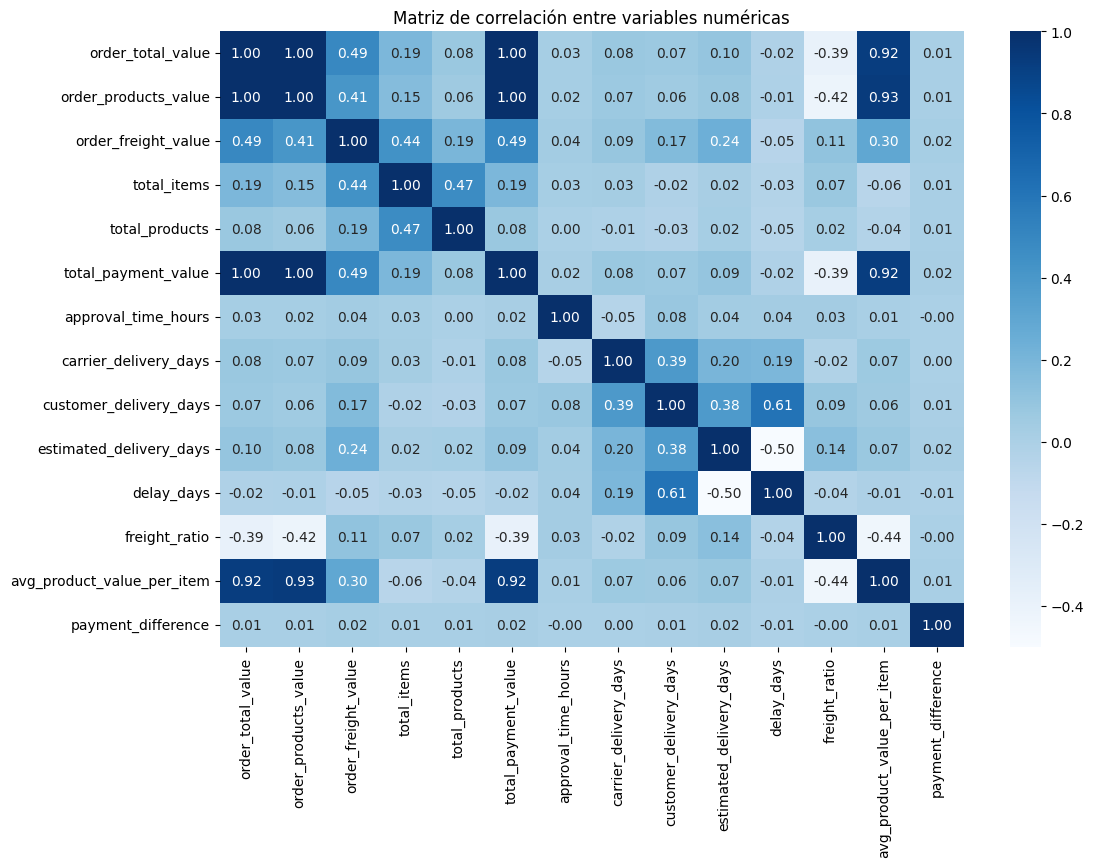

In [9]:
# Paso 9: visualizar matriz de correlación

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

In [10]:
# Paso 10: identificar correlaciones fuertes

def obtener_correlaciones_fuertes(matriz, umbral=0.7):
    """
    Extrae las correlaciones fuertes de una matriz de correlación.

    Parametros
    ----------
    matriz : pd.DataFrame
        Matriz de correlación.

    umbral : float, default=0.7
        Valor mínimo absoluto para considerar una correlación fuerte.

    Devuelve
    --------
    pd.DataFrame
        Pares de variables con correlación superior al umbral indicado.
    """

    matriz_abs = matriz.abs()

    mascara = np.triu(
        np.ones_like(matriz_abs),
        k=1
    ).astype(bool)

    correlaciones_filtradas = (
        matriz_abs
        .where(mascara)
        .stack()
        .reset_index()
    )

    correlaciones_filtradas.columns = [
        "variable_1",
        "variable_2",
        "correlacion"
    ]

    correlaciones_filtradas = (
        correlaciones_filtradas[
            correlaciones_filtradas["correlacion"] >= umbral
        ]
        .sort_values("correlacion", ascending=False)
    )

    return correlaciones_filtradas


obtener_correlaciones_fuertes(correlaciones, umbral=0.7)

,variable_1,variable_2,correlacion
4,order_total_value,total_payment_value,0.999987
0,order_total_value,order_products_value,0.995991
16,order_products_value,total_payment_value,0.995970
23,order_products_value,avg_product_value_per_item,0.933169
11,order_total_value,avg_product_value_per_item,0.921212
61,total_payment_value,avg_product_value_per_item,0.921196


In [11]:
# Paso 11: detectar outliers mediante el método IQR

def detectar_outliers_iqr(serie):
    """
    Detecta valores atípicos utilizando el método del rango intercuartílico.

    Un valor se considera outlier si se encuentra por debajo de:
    Q1 - 1.5 * IQR

    o por encima de:
    Q3 + 1.5 * IQR

    Parametros
    ----------
    serie : pd.Series
        Variable numérica sobre la que detectar outliers.

    Devuelve
    --------
    dict
        Diccionario con límites inferior y superior, número de outliers
        y porcentaje de outliers.
    """

    serie = serie.dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = (
        (serie < limite_inferior)
        |
        (serie > limite_superior)
    )

    resultado = {
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "numero_outliers": outliers.sum(),
        "porcentaje_outliers": outliers.mean() * 100
    }

    return resultado

In [12]:
# Paso 12: resumir outliers de las variables clave

def resumir_outliers(df, columnas):
    """
    Aplica la detección de outliers por IQR a varias columnas.

    Parametros
    ----------
    df : pd.DataFrame
        Dataset que contiene las columnas numéricas.

    columnas : list
        Lista de columnas sobre las que se quiere detectar outliers.

    Devuelve
    --------
    pd.DataFrame
        Resumen de outliers por variable.
    """

    resultados = []

    for columna in columnas:
        resultado = detectar_outliers_iqr(df[columna])
        resultado["variable"] = columna
        resultados.append(resultado)

    resumen = pd.DataFrame(resultados)

    columnas_orden = [
        "variable",
        "limite_inferior",
        "limite_superior",
        "numero_outliers",
        "porcentaje_outliers"
    ]

    resumen = resumen[columnas_orden]

    return resumen.round(2)


columnas_outliers = [
    "order_total_value",
    "order_products_value",
    "order_freight_value",
    "total_payment_value",
    "customer_delivery_days",
    "delay_days"
]

resumen_outliers = resumir_outliers(
    df,
    columnas_outliers
)

resumen_outliers

,variable,limite_inferior,limite_superior,numero_outliers,porcentaje_outliers
0,order_total_value,-110.36,349.21,7775,7.88
1,order_products_value,-110.10,305.90,7913,8.02
2,order_freight_value,-1.44,39.33,9941,10.08
3,total_payment_value,-110.43,349.41,7866,7.91
4,customer_delivery_days,-6.66,29.15,4899,5.08
5,delay_days,-31.03,8.39,4875,5.05


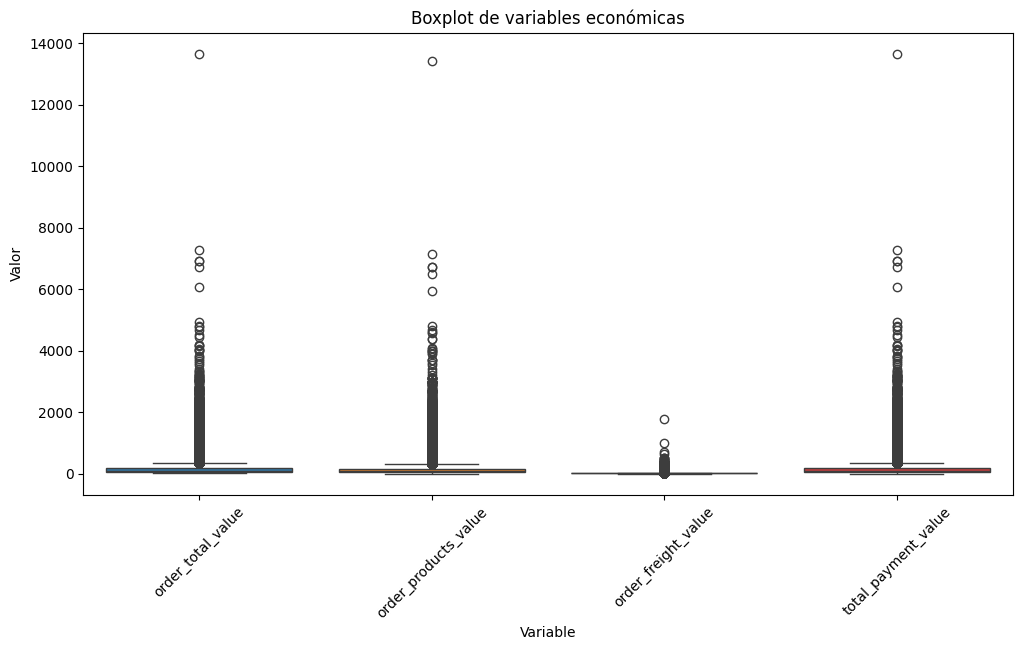

In [13]:
# Paso 13: visualizar outliers económicos con boxplot

columnas_economicas = [
    "order_total_value",
    "order_products_value",
    "order_freight_value",
    "total_payment_value"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[columnas_economicas]
)

plt.title("Boxplot de variables económicas")
plt.xlabel("Variable")
plt.ylabel("Valor")

plt.xticks(rotation=45)

plt.show()

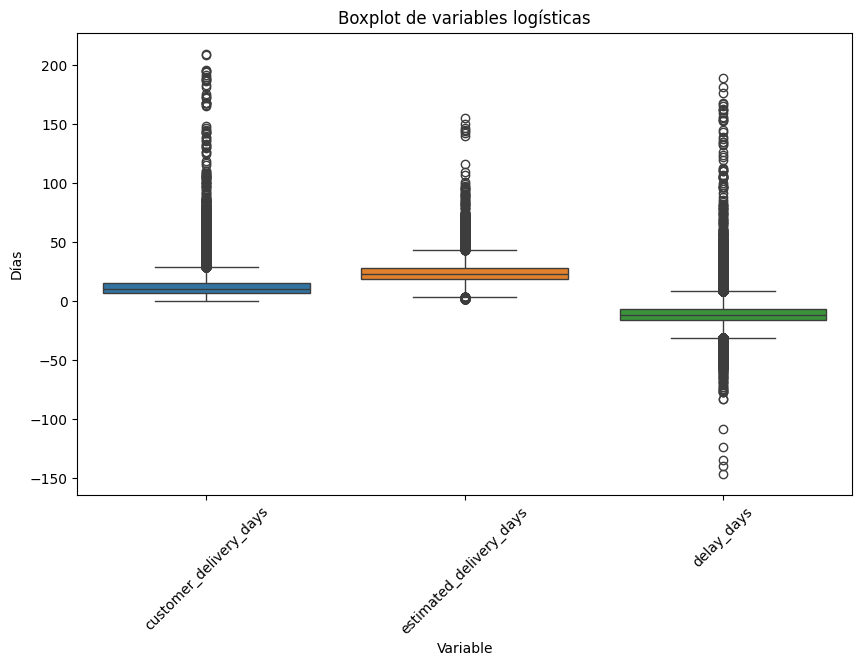

In [14]:
# Paso 14: visualizar outliers logísticos con boxplot

columnas_logisticas = [
    "customer_delivery_days",
    "estimated_delivery_days",
    "delay_days"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[columnas_logisticas]
)

plt.title("Boxplot de variables logísticas")
plt.xlabel("Variable")
plt.ylabel("Días")

plt.xticks(rotation=45)

plt.show()

In [15]:
# Paso 15: analizar ticket medio por segmento económico

ticket_segmento = (
    df.groupby("order_value_segment", observed=True)
    ["order_total_value"]
    .agg(["count", "mean", "median", "sum"])
    .round(2)
)

ticket_segmento

,count,mean,median,sum
order_value_segment,,,,
bajo,16855,36.91,37.58,622137.74
medio,49720,93.08,89.28,4628000.47
alto,27858,239.50,212.38,6672010.33
muy_alto,4233,926.39,737.62,3921404.70


In [16]:
# Paso 16: analizar retrasos por segmento económico

retrasos_segmento = (
    df.groupby("order_value_segment", observed=True)
    ["is_late"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

retrasos_segmento.columns = [
    "segmento",
    "porcentaje_retrasos"
]

retrasos_segmento

,segmento,porcentaje_retrasos
0,bajo,6.90
1,medio,7.84
2,alto,8.54
3,muy_alto,9.12


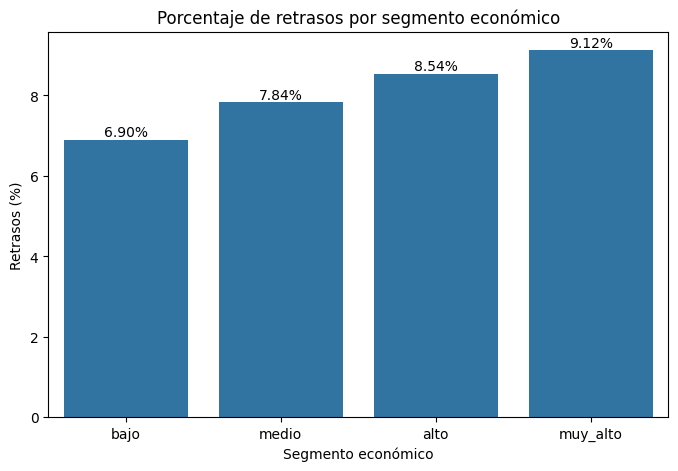

In [17]:
# Paso 17: visualizar retrasos por segmento económico

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=retrasos_segmento,
    x="segmento",
    y="porcentaje_retrasos"
)

for barra in ax.patches:
    ax.annotate(
        f"{barra.get_height():.2f}%",
        (
            barra.get_x() + barra.get_width() / 2,
            barra.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.title("Porcentaje de retrasos por segmento económico")
plt.xlabel("Segmento económico")
plt.ylabel("Retrasos (%)")

plt.show()

In [18]:
# Paso 18: analizar ticket medio en festivos y días no festivos

ticket_festivo = (
    df.groupby("is_holiday")
    ["order_total_value"]
    .agg(["count", "mean", "median"])
    .round(2)
    .reset_index()
)

ticket_festivo["is_holiday"] = (
    ticket_festivo["is_holiday"]
    .map({
        0: "No festivo",
        1: "Festivo"
    })
)

ticket_festivo

,is_holiday,count,mean,median
0,No festivo,95985,160.71,105.29
1,Festivo,2681,155.94,104.70


In [20]:
# Paso 19: analizar diferencias logísticas entre pedidos en plazo y retrasados

columnas_logisticas_retrasos = [
    "customer_delivery_days",
    "delay_days",
    "order_freight_value"
]

logistica_retrasos = (
    df
    .groupby("is_late")[columnas_logisticas_retrasos]
    .agg(["count", "mean", "median"])
    .round(2)
)

logistica_retrasos

customer_delivery_days               delay_days                \
                         count   mean median      count   mean median   
is_late                                                                 
0                        88649  10.88   9.73      88649 -13.01 -12.32   
1                         7827  31.52  29.16       7827   9.55   5.81   

        order_freight_value                
                      count   mean median  
is_late                                    
0                     90839  22.67  17.07  
1                      7827  24.62  18.05

In [22]:
resumen = resumen_estadistico(df_numerico)

resumen_outliers = resumir_outliers(
    df,
    columnas_outliers
)

In [23]:
# Paso 20: guardar tablas estadísticas principales

resumen_estadistico(df_numerico).to_csv(
    "../data/processed/resumen_estadistico.csv"
)

resumir_outliers(
    df,
    columnas_outliers
).to_csv(
    "../data/processed/resumen_outliers.csv",
    index=False
)

print("Archivos guardados correctamente")

Archivos guardados correctamente
